<a href="https://colab.research.google.com/github/Jackline-Jebet/ML-Data-Science-Financial-Data/blob/main/Special_Matrices_For_Equity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1.3. Covariance Matrix
# . A covariance matrix is a square matrix giving the variances of the variables on the diagonal of the matrix and the covariances between each pair of the variables on the off-diagonal.
# Let's calculate the covariance matrix for stock returns for Apple, Ford Motor, and Walmart as an example.

import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yfin
import seaborn as sns

In [2]:
# Download stock prices from Yahoo Finance and set the time period for download
start = datetime.date(2018, 1, 2)
end = datetime.date(2023, 12, 31)
stocks = yfin.download(["AAPL", "F", "WMT"], start, end, auto_adjust = False)["Adj Close"]
stocks.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,F,WMT
Date,,,
2018-01-02,40.426826,8.470927,29.041025
2018-01-03,40.419785,8.537838,29.294352
2018-01-04,40.607540,8.685043,29.320860
2018-01-05,41.069859,8.832248,29.494656
2018-01-08,40.917332,8.798792,29.930603


In [3]:
stocks.index = pd.to_datetime(stocks.index).strftime("%Y-%m-%d")

In [4]:
# In order to calculate the returns of the stocks, we need to drop the NA rows.
stocks_returns = stocks[["AAPL", "F", "WMT"]].dropna().pct_change()
stocks_returns = stocks_returns.dropna()
stocks_returns.head()

Ticker,AAPL,F,WMT
Date,,,
2018-01-03,-0.000174,0.007899,0.008723
2018-01-04,0.004645,0.017242,0.000905
2018-01-05,0.011385,0.016949,0.005927
2018-01-08,-0.003714,-0.003788,0.014781
2018-01-09,-0.000115,-0.005323,-0.012006


In [5]:
# Calculate covariance matrix for Apple, Ford Motor and Walmart
# Use np.allclose to verify if the matrix is a symmetric matrix
stock_returns_covariance_matrix = stocks_returns.cov()
print("Apple, Ford Motor and Walmart Covariance Matrix:")
print(stock_returns_covariance_matrix)
print("\nIs the covariance matrix symmetric?", np.allclose(stock_returns_covariance_matrix, stock_returns_covariance_matrix.T))

Apple, Ford Motor and Walmart Covariance Matrix:
Ticker      AAPL         F       WMT
Ticker                              
AAPL    0.000398  0.000194  0.000103
F       0.000194  0.000668  0.000068
WMT     0.000103  0.000068  0.000199

Is the covariance matrix symmetric? True


In [8]:
# 1.4. Correlation Matrix
# correlation is a metric to measure the co-movement of two variables while removing their scales.
# Calculate correlation matrix for Apple, Ford Motor and Walmart
# Verify if a correlation matrix a symmetric matrix
stock_returns_correlation_matrix = stocks_returns.corr()
print("Apple, Ford Motor and Walmart Correlation Matrix:")
print(stock_returns_correlation_matrix)
print("\nIs the correlation matrix symmetric?", np.allclose(stock_returns_correlation_matrix, stock_returns_correlation_matrix.T))

# The diagonal values are the correlations of 3 stocks to themselves. The off-diagonal values are the correlations of different paired stock returns. Apple's stock return has similar correlation to both Ford Motor and Walmart's stock returns. Ford Motor and Walmart's stock returns have the lowest correlation among other stock return pairs.

Apple, Ford Motor and Walmart Correlation Matrix:
Ticker      AAPL         F       WMT
Ticker                              
AAPL    1.000000  0.376460  0.365246
F       0.376460  1.000000  0.185248
WMT     0.365246  0.185248  1.000000

Is the correlation matrix symmetric? True


In [9]:
# 1.5. Converting between Covariance and Correlation Matrices
# Convert covariance to correlation
def cov_to_corr(cov_matrix):
    d = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(d, d)
    return corr_matrix

# Convert correlation to covariance
def corr_to_cov(corr_matrix, std_devs):
    cov_matrix = corr_matrix * np.outer(std_devs, std_devs)
    return cov_matrix


In [10]:
# Use our Apple, Ford Motor and Walmart stock returns example to demonstrate the conversion
# Calculate standard deviations of stock returns
stocks_returns_std = stocks_returns.std()

#convert covariance to correlation example
cov_to_corr(stock_returns_correlation_matrix)

Ticker,AAPL,F,WMT
Ticker,,,
AAPL,1.000000,0.376460,0.365246
F,0.376460,1.000000,0.185248
WMT,0.365246,0.185248,1.000000


In [11]:
#convert correlation to covariance example
corr_to_cov(stock_returns_correlation_matrix, stocks_returns_std)

Ticker,AAPL,F,WMT
Ticker,,,
AAPL,0.000398,0.000194,0.000103
F,0.000194,0.000668,0.000068
WMT,0.000103,0.000068,0.000199


In [12]:
# 2. Triangular Matrix
# A triangular matrix is a square matrix where all the entries on one side of the main diagonal are zero. There are two types of triangular matrices: lower triangular matrix and upper triangular matrix.
# 2.1. Lower Triangular Matrix is a square matrix whose entries above the main diagonal are zero.
# 2.2. Upper Triangular Matrix is a square matrix whose entries below the main diagonal are zero.
# 2.3. Properties of a Triangular Matrix
#   1. The determinant is the product of the diagonal elements.
#   2. The inverse of a triangular matrix (if it exists) is also triangular.
#   3. The product of two upper (or lower) triangular matrices is upper (or lower) triangular.

In [13]:
# 3. Symmetric Positive Definite (PD) Matrices and Symmetric Positive Semi-Definite (SPD) Matrices
# 3.1. Symmetric Positive Definite (PD) Matrices
# key properties of a symmetric positive definite matrix:

#   1. All eigenvalues of the matrix are positive
#   2. The determinant of the matrix is positive
#   3. The matrix has full rank
#   4. The matrix is invertible
#   5. The summation and multiplication of two symmetric positive definite matrices is also a symmetric positive definite matrix


In [14]:
# 3.2. Symmetric Positive Semidefinite (SPD) Matrices
# key properties of a symmetric positive semidefinite matrix:

#   1. All eigenvalues of the matrix are non-negative
#   2. The determinant of the matrix is non-negative
#   3. The matrix may not have full rank
#   4. The matrix is not always invertible

In [15]:
# check if a matrix is a symmetric positive definite or a symmetric positive semidefinite.
def is_positive_definite(matrix):
    return np.all(np.linalg.eigvals(matrix) > 0)

A = stock_returns_correlation_matrix

print("Is A positive definite?", is_positive_definite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive definite? True
Eigenvalues: [1.62523756 0.559898   0.81486444]
Determinant: 0.7414999610440519
Rank: 3


In [16]:
def is_positive_semidefinite(matrix):
    return np.all(np.linalg.eigvals(matrix) >= 0)

A = stock_returns_correlation_matrix

print("Is A positive semidefinite?", is_positive_semidefinite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive semidefinite? True
Eigenvalues: [1.62523756 0.559898   0.81486444]
Determinant: 0.7414999610440519
Rank: 3


In [18]:
# 4. Cholesky Factorization
# 4.1. Definition of Cholesky Factorization
# Cholesky factorization is a method to decompose a symmetric matrix. Cholesky factorization states that a symmetric positive definite matrix can be decomposed as follows:
# 𝑆=𝐿𝐿𝑇 where  𝐿 is a lower triangular matrix or a Cholesky factor.

# Python Numpy has a function to calculate the Choleksy factor for a matrix
S= np.array([[25,15,-5],
             [15,18,0],
             [-5,0,11]])

L_numpy = np.linalg.cholesky(S)
print("\nNumPy Cholesky factor:")
print(L_numpy)

# Choleksy factorization algorithum greatly improves the computer efficiency to solve for linear equations. It can also be used to compute the inverse of a matrix more efficiently than some other methods. Choleksy factorization is also numerically stable, making it useful for computations involving ill-conditioned matrices.


NumPy Cholesky factor:
[[ 5.  0.  0.]
 [ 3.  3.  0.]
 [-1.  1.  3.]]


In [19]:
# 4.2. Using Cholesky Factorization for Monte Carlo Simulation to generate correlated random variables.
# calculate the correlation of Apple and Ford Motor stock returns
# Create a new dataframe with just Apple and Ford Motor stock returns from the dataframe from the last example
two_stock_returns = stocks_returns[["AAPL", "F"]]
original_correlation = two_stock_returns.corr()
original_correlation

Ticker,AAPL,F
Ticker,,
AAPL,1.00000,0.37646
F,0.37646,1.00000


In [20]:
# Create a function to generate random samples from correlated variables
def generate_correlated_samples(n_samples, correlation_matrix):
    # Compute Cholesky factorization
    L = np.linalg.cholesky(correlation_matrix)

    # Generate independent standard normal samples
    Z = np.random.standard_normal((correlation_matrix.shape[0], n_samples))

    # Generate correlated samples
    X = L @ Z

    return X


# Generate samples
n_samples = 10000
X = generate_correlated_samples(n_samples, original_correlation)
X = pd.DataFrame(generate_correlated_samples(n_samples, original_correlation).T, columns = ["APPL","F"])
# Compute sample correlation
sample_correlation = X.corr()

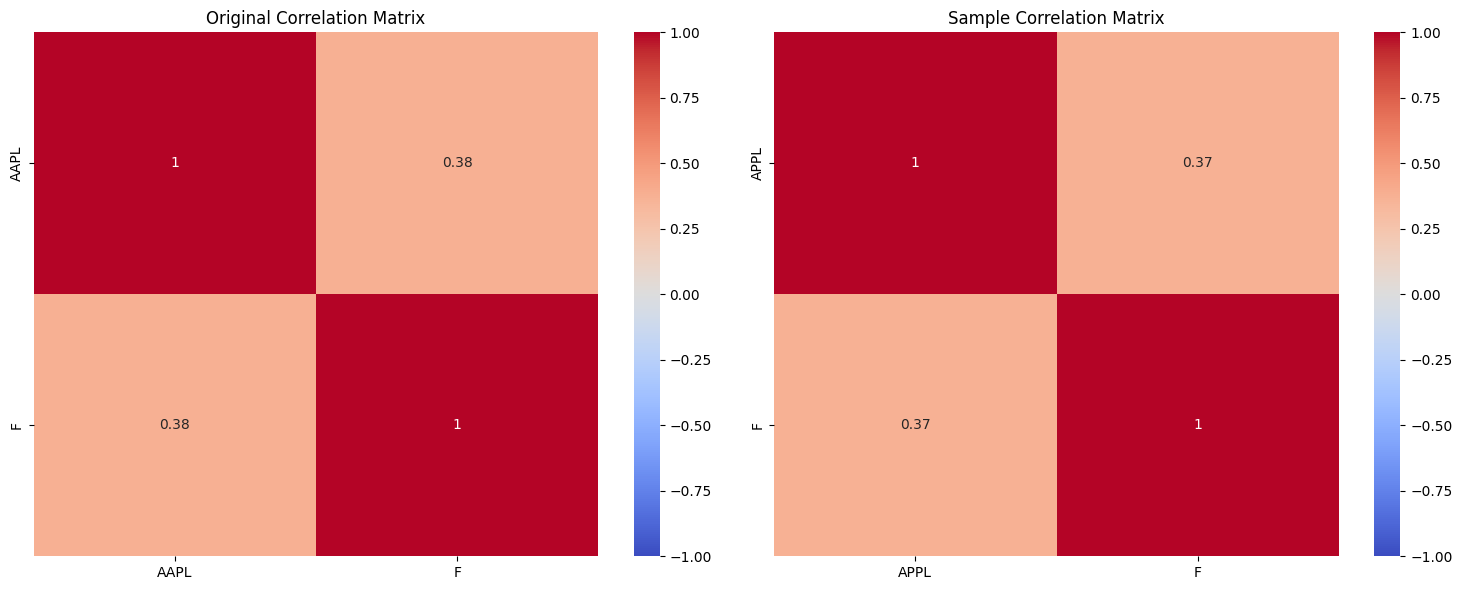

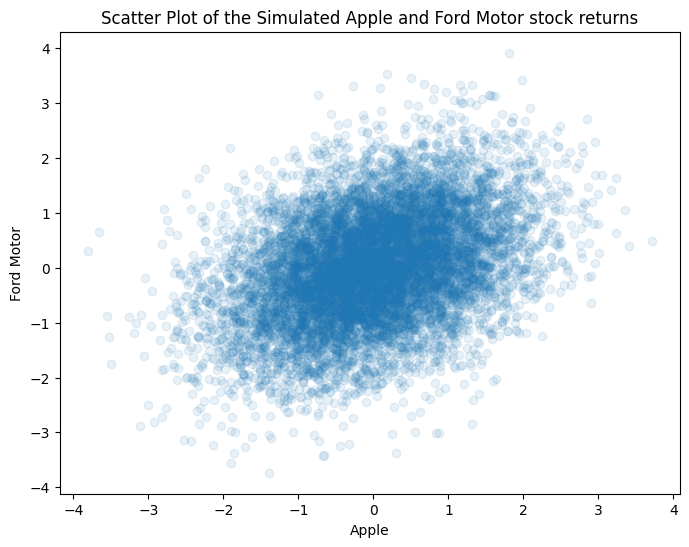

In [21]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(original_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Original Correlation Matrix')
ax1.set(xlabel='', ylabel='')


sns.heatmap(sample_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Sample Correlation Matrix')
ax2.set(xlabel='', ylabel='')

plt.tight_layout()
plt.show()

# Scatter plot of the stimulated Apple and Ford Motor stock returns
plt.figure(figsize=(8, 6))
plt.scatter(X["APPL"], X["F"], alpha=0.1)
plt.title('Scatter Plot of the Simulated Apple and Ford Motor stock returns')
plt.xlabel('Apple')
plt.ylabel('Ford Motor')
plt.show()